In [2]:
import argparse
import io
import os
import time
import warnings

import numpy as np
import pandas as pd
import planetary_computer
import pystac_client
import rioxarray  # rioxarray is required for the .rio methods in xarray despite what mypy, ruff, etc. says :)
import stackstac
from tqdm import tqdm
import matplotlib.pyplot as plt
import dask

In [3]:
# parquet_file = "/mnt/rolf-datastore/home/leca5365/Documents/satclip/notebooks/s2l2a_2_5_2024_clouds_lt_20_date_gt_2021_01_01.parquet"
# parquet_file = "/Users/leca5365/Library/CloudStorage/OneDrive-UCB-O365/Documents/satclip/scripts/s2l2a_2_5_2024_clouds_lt_20_date_gt_2021_01_01.parquet"
parquet_file = "../scripts/landsat_4_5_1982_08_22_to_2012_05_05.parquet"

df = pd.read_parquet(parquet_file)
num_rows = df.shape[0]

test_id = df.iloc[100]["id"]
test_id

'LT04_L2SP_034034_19821123_02_T1'

In [4]:
len(df)

1168520

In [47]:
# Connect to Microsoft Planetary Computer STAC API
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1/",
    modifier=planetary_computer.sign_inplace,
)

collection = catalog.get_collection("landsat-c2-l2")

item = collection.get_item(test_id)


In [52]:
item

<Item id=LT04_L2SP_034034_19821123_02_T1>

In [48]:
str(item.properties.get("instruments", ""))

"['tm']"

In [49]:
# Connect to Microsoft Planetary Computer STAC API
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1/",
    modifier=planetary_computer.sign_inplace,
)

collection = catalog.get_collection("landsat-c2-l2")

item = collection.get_item(test_id)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    stack = stackstac.stack(
        item,
        assets=[
            "blue",
            "green",
            "red",
            "nir08",
            "swir16",
            "lwir",
            "swir22",
            "qa_pixel",
            "qa_radsat",
            "cloud_qa",
            "qa"
        ],
        epsg=32612,
    )
_, num_channels, height, width = stack.shape

# Randomly sample a 256x256 window within image bounds
x = np.random.randint(0, width - 256)
y = np.random.randint(0, height - 256)

# Extract patch and compute in-memory
# patch = stack[0, :, y : y + 256, x : x + 256].compute()
patch = stack[0, :, y : y + 256, x : x + 256].compute()

In [50]:
stack

<xarray.DataArray 'stackstac-4564e331c2ce94e0863232f950848376' (time: 1,
                                                                band: 11,
                                                                y: 7182, x: 7942)> Size: 5GB
dask.array<fetch_raster_window, shape=(1, 11, 7182, 7942), dtype=float64, chunksize=(1, 1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates: (12/33)
  * time                         (time) datetime64[ns] 8B 1982-11-23T17:12:40...
  * band                         (band) <U9 396B 'blue' 'green' ... 'qa'
  * y                            (y) float64 57kB 4.272e+06 ... 4.041e+06
  * x                            (x) float64 64kB 7.556e+05 ... 1.008e+06
    id                           (time) <U31 124B 'LT04_L2SP_034034_19821123_...
    proj:transform               object 8B {0.0, -30.0, 4256715.0, 231885.0, ...
    ...                           ...
    title                        (band) <U64 3kB 'Blue Band' ... 'Surface Tem...
    classification:bitfields     (band) object 88B None None ... None
    common_name                  (band) object 88B 'blue' 'green' ... None None
    center_wavelength            (band) object 88B 0.49 0.56 0.66 ... None None
    full_width_half_max          (band) object 88B 0.07 0.08 0.06 ... None None
    epsg                         int64 8B 32612
Attributes:
    spec:           RasterSpec(epsg=32612, bounds=(755550.839387034, 4041086....
    crs:            epsg:32612
    transform:      | 31.76, 0.00, 755550.84|\n| 0.00,-32.14, 4271905.15|\n| ...
    resolution_xy:  (31.764518598630875, 32.13843570422902)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.06224000000000002..1.6022125].


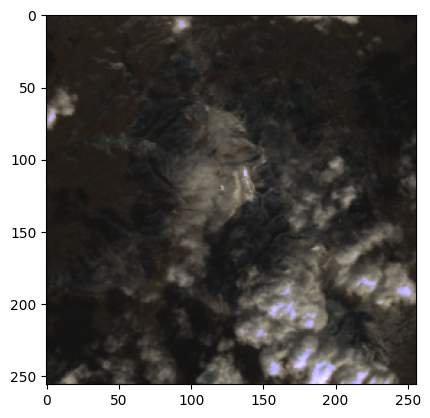

In [51]:
# red_band = patch[2, :, :] / 10000.0
# green_band = patch[1, :, :] / 10000.0
# blue_band = patch[0, :, :] / 10000.0
red_band = patch[2, :, :] 
green_band = patch[1, :, :] 
blue_band = patch[0, :, :] 
rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)

# Plot the RGB image
plt.imshow(rgb_image)
# plt.imshow(patch[8, :, :])

In [147]:
np.any(df["s2:saturated_defective_pixel_percentage"].iloc[np.random.randint(0, num_rows, size=batch_size)] > 0)

np.False_

In [38]:
# Batch example
batch_size = 100
batch_ids = df["id"].iloc[np.random.randint(0, num_rows, size=batch_size)].tolist()
items = catalog.search(
    collections=["sentinel-2-l2a"],
    ids=batch_ids,
).item_collection()

# Download raster data for items
stacks = []
for item in items:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stack = stackstac.stack(
            item,
            assets=[
                "B01",
                "B02",
                "B03",
                "B04",
                "B05",
                "B06",
                "B07",
                "B08",
                "B8A",
                "B09",
                "B11",
                "B12",
            ],
            epsg=4326,
        )
    stacks.append(stack)
xs = [np.random.randint(0, width - 256) for width in [stack.shape[3] for stack in stacks]]
ys = [np.random.randint(0, height - 256) for height in [stack.shape[2] for stack in stacks]]
stacks_sampled = [stack[0, :, y : y + 256, x : x + 256] for stack, x, y in zip(stacks, xs, ys)]

print("Ship it")
patches = dask.compute(*stacks_sampled, scheduler="threads", num_workers=12)

Ship it


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.6624..1.1945].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1426..1.0784].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1257..1.6294].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1086..1.0884].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0929..1.13].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.944..1.0688].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1447..1.392].
Clipping input data to the valid range

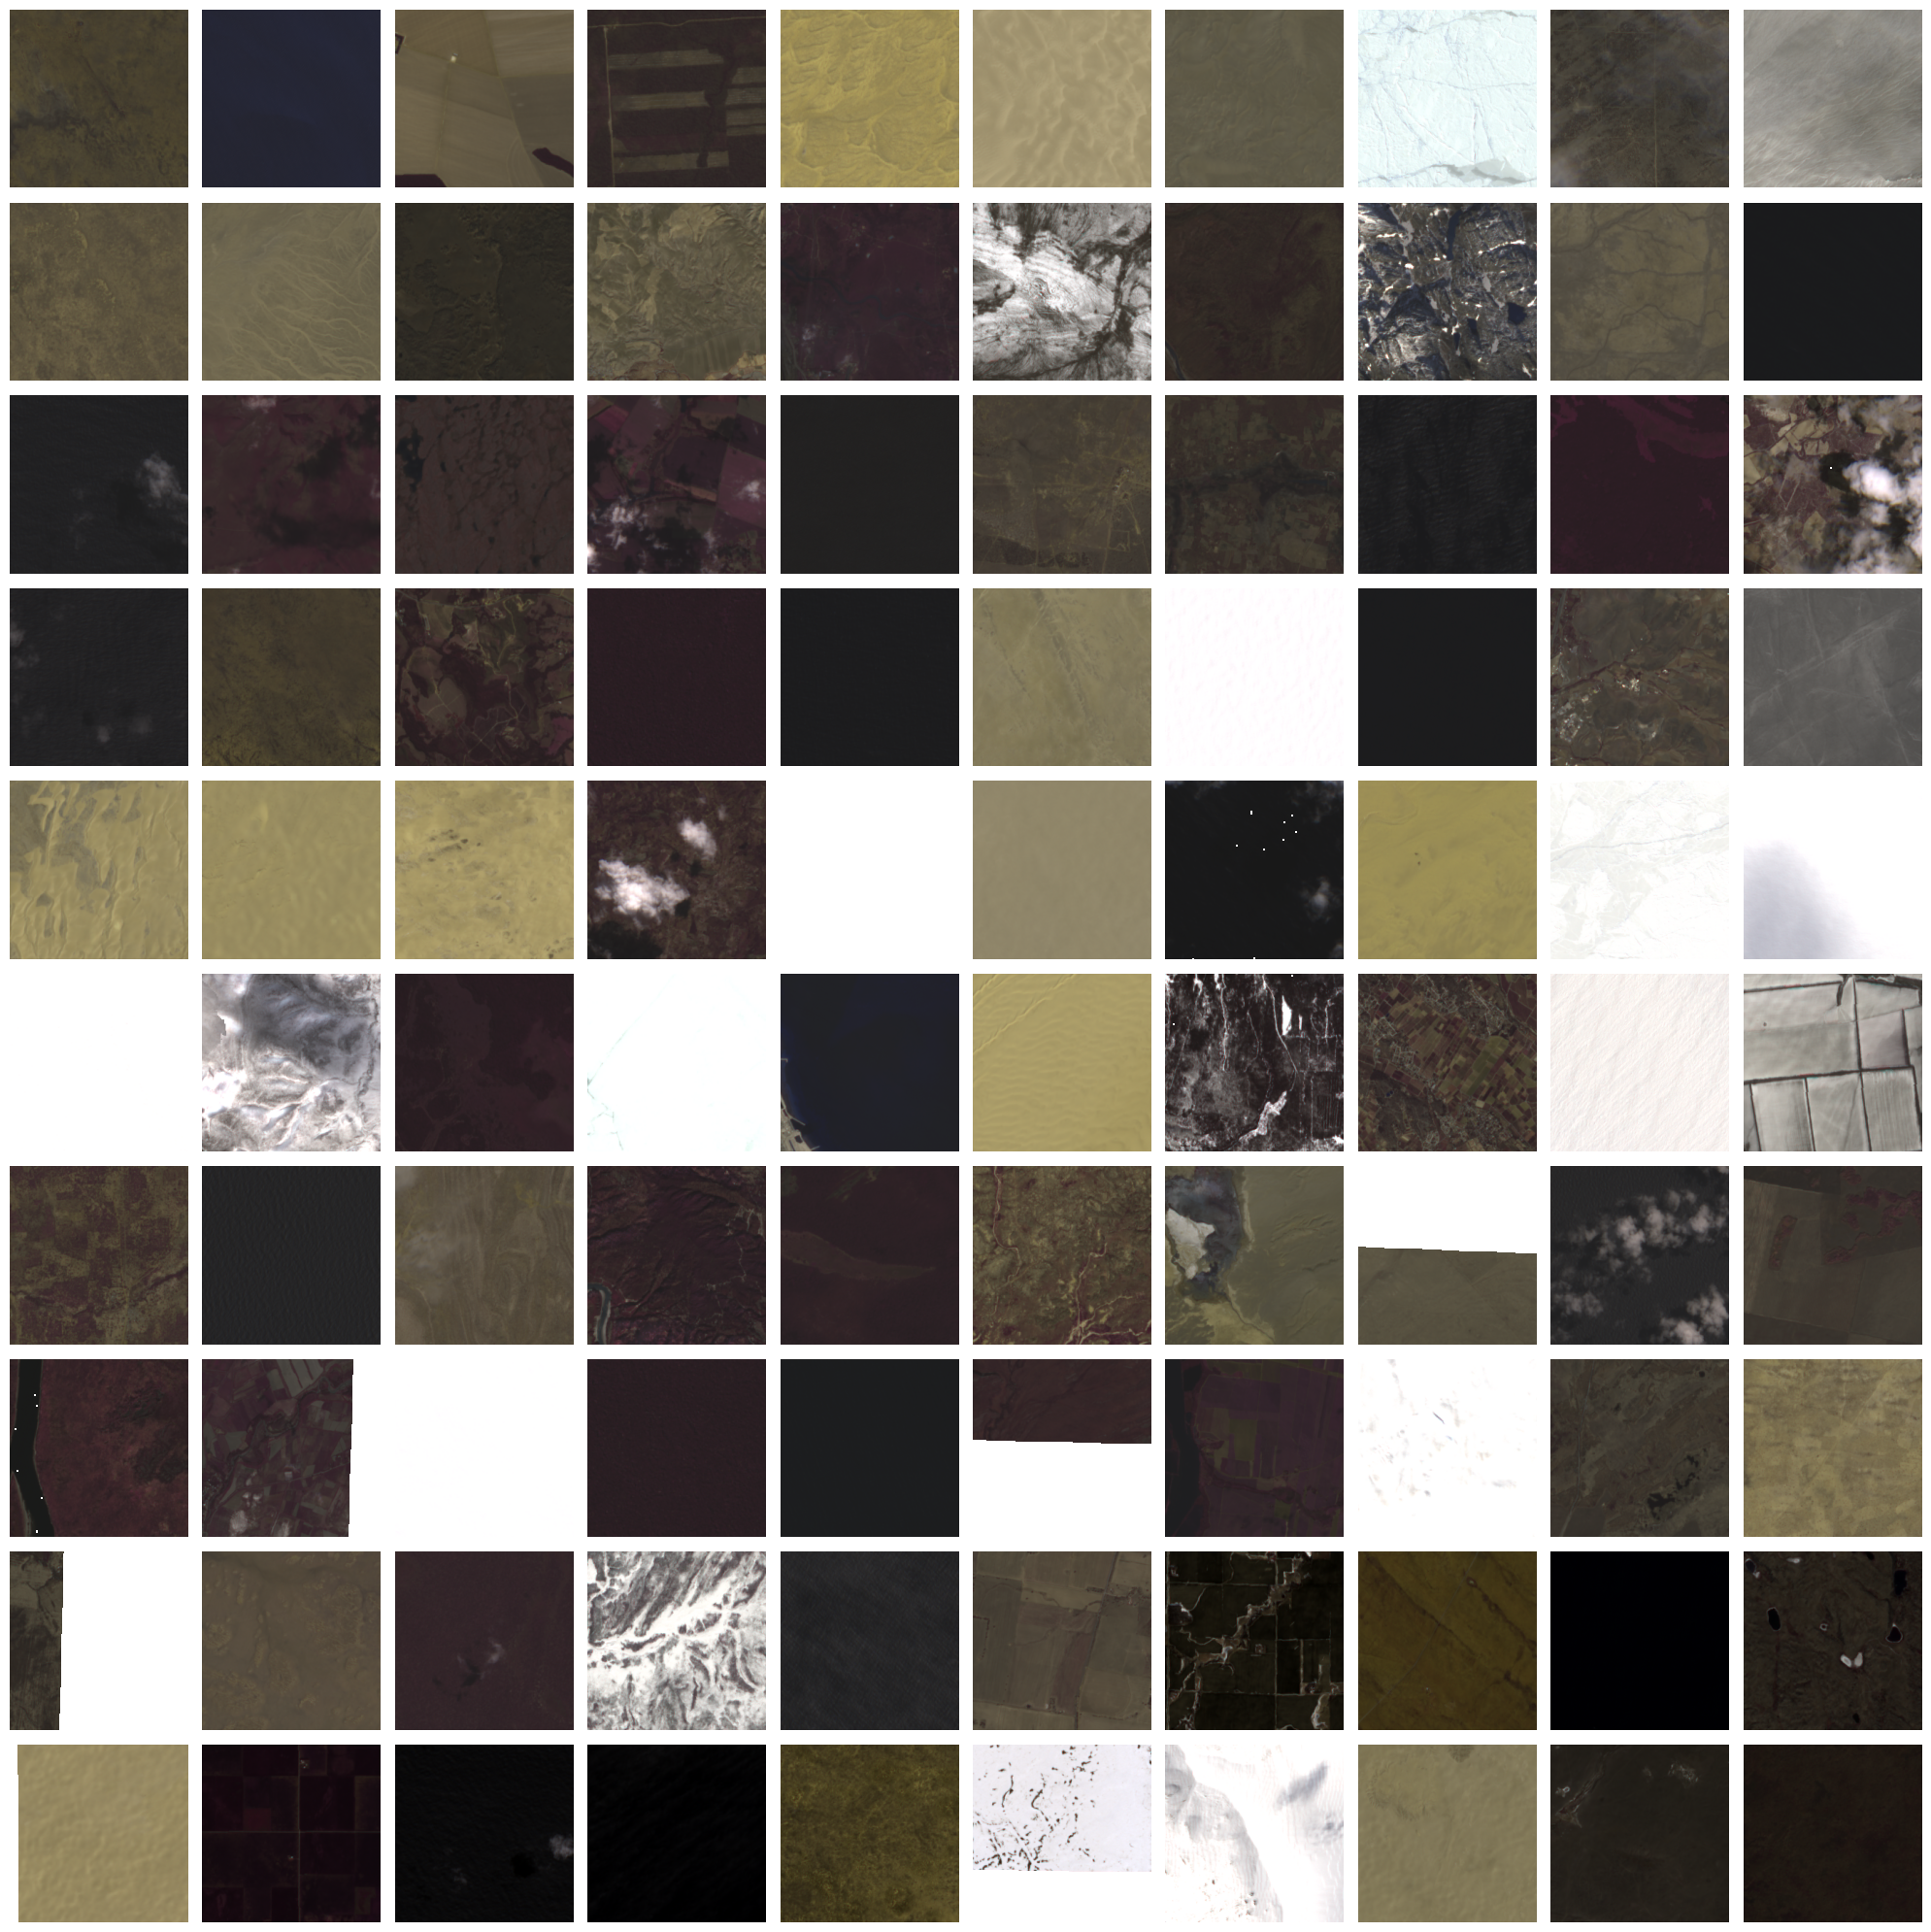

In [39]:
# Visualize composite of 10x10 grid of RGB patches
fig, axes = plt.subplots(10, 10, figsize=(20, 20))
for i in range(10):
    for j in range(10):
        idx = i * 10 + j
        if idx < len(patches):
            patch = patches[idx]
            red_band = patch[4, :, :] / 10000.0
            green_band = patch[3, :, :] / 10000.0
            blue_band = patch[2, :, :] / 10000.0
            rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)
            axes[i, j].imshow(rgb_image)
            axes[i, j].axis("off")
plt.tight_layout()